# TEST SEGMENTACIÓN PARA EXPORTAR MÁSCARAS

In [1]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpike

Mounted at /content/drive/
/content/drive/MyDrive/StereoSpike


## Instalar librerías

In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 42.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia

## Importar librerías

In [3]:
import time
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import h5py
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms

# from network.SNN_models2 import unetMotion3, unetMotion4
from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, \
                    PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, \
                    NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, \
                    NeuronPool_Separable_Pool3d_3x3

from network.ANN_models import StereoSpike_equivalentANN
from network.Params import yamlParams
from network.loss2 import Total_Loss_Motion, DiceLoss, BCEDiceLoss, getIOU
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase, EVIMODatasetBaseNPZ


from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os

########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)

##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## Parámetros del dataset
Probablemente no se usa

In [16]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"

incrementalPercent  = 1
saveImages = True
imageLabel = ""

output_dir = "/content/drive/MyDrive/StereoSpike/logs/" # os.path.join(os.getcwd(), 'logs')

general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)

In [17]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network
from OF_EV_SNN.network_3d.poolingNet_cat_1res import PLIFNeuronPool_Separable_Pool3d # PLIFNeuronPool_Separable_Pool3d_state


net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 1.).to(device) #ts 21

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))

# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

# learning_rate = 2e-3
# weight_decay = 0.0
# learned_metric = 'LIN'
# # Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40], gamma = 0.5)

# loss_module = BCEDiceLoss()

USING SPIKING MODEL
Trainable parameters: 1069226


## Load logging

In [7]:
# checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_data_inverse_super2.pth")
# checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/poolingnet_seg_lif3x3_floor_max8_5_batch1_super.pth")
# checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lab_part2_no_final.pth")
checkpoint = torch.load("/content/drive/MyDrive/StereoSpike/results/checkpoints/poolingnet_seg_lif3x3_wall_max1_5_batch1_lr_5_3_super.pth")
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# epoch_load = checkpoint['epoch']
# epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)

<All keys matched successfully>

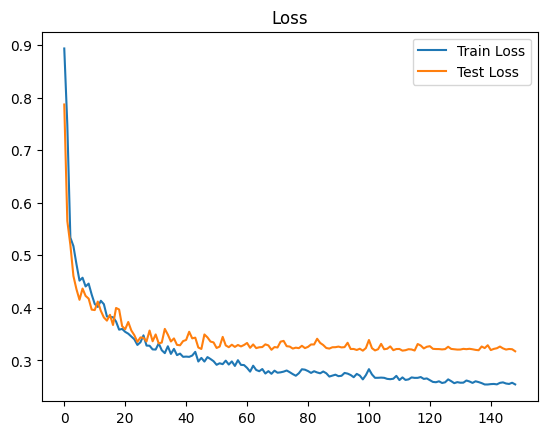

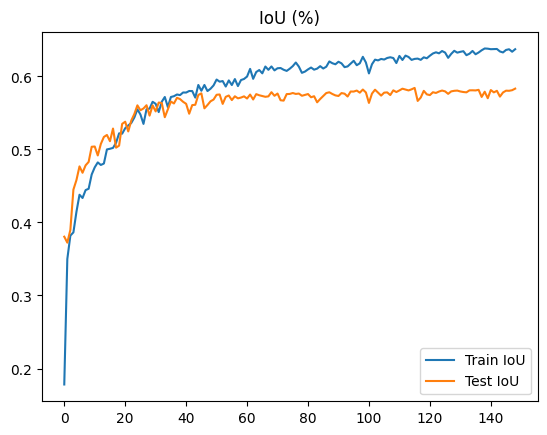

0.25451660756435657
0.3174954056739807
0.6371870114013819
0.5832211491373116


In [8]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'-',y,test_loss_vec,'-')
plt.title("Loss")
plt.legend(['Train Loss', 'Test Loss'])
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'-',y,test_error_vec, '-')
plt.title("IoU (%)")
plt.legend(['Train IoU', 'Test IoU'],loc = "lower right")
plt.show()

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

## Test

In [9]:
# try:
#   print(epoch_load)
# except:
#   epoch_load = 0

# print(epoch_load)

print(train_loss_vec[-1])
print(test_loss_vec[-1])
print(train_error_vec[-1])
print(test_error_vec[-1])

# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

0.25451660756435657
0.3174954056739807
0.6371870114013819
0.5832211491373116


In [11]:
# data = h5py.File('/media/lapyrcio/MP/Dani/Dataset MVSEC/indoor_flying/indoor_flying4_data.hdf5','r')
# data = h5py.File('/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/hdf5/indoor_flying/indoor_flying4_data.hdf5','r')
data = h5py.File('/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/hdf5/outdoor_day/outdoor_day2_data.hdf5','r')
images = data['davis']['left']['image_raw']
image_ts = data['davis']['left']['image_raw_ts']
image_raw_event_inds = data['davis']['left']['image_raw_event_inds']
events = data['davis']['left']['events']

print('images: ', len(images))
print('images: ', images.shape)
print('image_ts: ', len(image_ts))
print('image_raw: ', len(image_raw_event_inds))
print('image_raw: ', image_raw_event_inds[0:5])
print('events: ', len(events))

start_indx = 0 #image_raw_event_inds
start_time = image_ts[0] - 0.032                  # El 0.032 es de

images:  28583
images:  (28583, 260, 346)
image_ts:  28583
image_raw:  28583
image_raw:  [ -1  37 124 197 253]
events:  466410069


### Multiple dataset loader WALL completo 10 ms

In [10]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [11]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

# hyperparameters_report = \
#     '''
#     MODEL
#     ------------------------------
#     {}
#     DATA
#     ------------------------------
#     nfpdm = {}
#     N_train = {}
#     training_set = {}
#     test_set = {}
#     learned_metric = {}
#     data_augmentation = {}
#     SHUFFLED TRAINING PROCEDURE
#     ------------------------------
#     batchsize = {}
#     lr = {}
#     wd = {}
#     '''.format(net._get_name(),

#                nfpdm,
#                N_inference,
#                len(train_loader),
#                len(test_loader),
#                learned_metric,
#                tsfm,

#                batch_size,
#                learning_rate,
#                weight_decay)

# logfile.write(hyperparameters_report)
# print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 1593
MVSEC_dataset1
EVIMO tot length 1784
MVSEC_dataset1
EVIMO tot length 1401
MVSEC_dataset1
EVIMO tot length 1957
MVSEC_dataset1
EVIMO wall used


## Test

In [12]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning, show_learning_eval


with torch.no_grad():
    for j in range(5,len(image_ts)-1): #(100,200):
        #start_time = image_ts[i] #
        stop_time = image_ts[j] #

        # functional.reset_net(net)

        stop_indx = image_raw_event_inds[j] # para la primera = 107
        freq = stop_time - start_time

        event_window_list = events[start_indx:stop_indx]

        # event_array = np.zeros((2,260,346,int((stop_time - start_time)/0.001))) # polarity, height, width, ts
        event_array = torch.zeros((2,260,346,21))

        #print(((stop_time - start_time)/0.001)-21)

        ts_prev = start_time
        count = 0

        time_start_process = time.time()

        len_eve = 0

        #for ts in range(start_time + 0.001, stop_time, 0.001):

        for i in range(int((stop_time - start_time)/0.001)-21, int((stop_time - start_time)/0.001)):
            ts = 0.001*(i+1) + start_time
            event_window = event_window_list[(event_window_list[:,2] > ts_prev) & (event_window_list[:,2] <= ts)]
            event_x = event_window[:,0]
            event_y = event_window[:,1]
            #print(event_x.shape)
            event_p = np.where(event_window[:,3] == 1, 0, 1)

            #print(len(event_x))
            if len(event_x) != 0:
                event_array[event_p, event_y.astype(int), event_x.astype(int), count] = 1
            count += 1
            len_eve += len(event_window)
            # print(i)

        if len_eve > 30000:
            spike_input = (event_array.permute(0,3,1,2)).to(device)   # [Polarity, Height, Width, Ts] to [Polarity, Ts, Height, Width]
            spike_pred_list = net(spike_input[None,:,:,:,:])                # len(spike_pred_list) = 4  spike_input = torch.Size([B,C,T,260, 346])
            spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            # functional.reset_net(net)



            # show_learning_eval(fig,False,
            #               spike_input[None,:,:,:,:],
            #               spike_pred, 'segm, batch ', j)
            show_learning(fig,False,
                          spike_input[None,:,:,:,:],
                          spike_pred, 'segm, batch ', j)
        time_stop_process = time.time()
        ts_prev = ts


        start_time = stop_time + 0.001
        start_indx = stop_indx

NameError: name 'image_ts' is not defined

In [ ]:
!nvidia-smi

Thu Apr 20 03:11:52 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-SXM...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0    52W / 400W |  40485MiB / 40960MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [18]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)
n_epochs = 300
test_i = 0

net = net.eval()

running_test_loss = 0
running_test_IOU = 0

with torch.no_grad():
    start_time = time.time()
    show = True
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        test_i += 1
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']

        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)

        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()
        start_time_net = time.time()
        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
        stop_time_net = time.time()
        print("Test time: ", stop_time_net - start_time_net)

        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)

        spike_pred = torch.sigmoid(spike_pred)

        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
        spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
        spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

        if show:
            #condition to colapse all timesteps in every batch
            spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
            spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning(fig,False,
                              spike_input_5D[None,e,:,:,:,:],
                              spike_pred_4D[None,e,:,:,:],
                              spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

        loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)

        running_test_loss += loss / spikes_input.size(0)
        spike_pred = torch.round(spike_pred)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    if test_i != 0:
        epoch_test_loss = running_test_loss / test_i #len(test_loader)
        epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
        print("\n test i: ",test_i)
        print("len test loader: ", len(test_loader))
        # test_loss_vec.append(float(epoch_test_loss))
        test_error_vec.append(float(epoch_test_IOU))
        # test_error_vec.append(float(epoch_test_IOU[-1]))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(0, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(test_epoch_summary)


    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU (%)")
    plt.show()
print("training finished !")

testing:   1%|          | 22/2994 [00:01<04:01, 12.33it/s]


RuntimeError: Calculated padded input size per channel: (2 x 134 x 177). Kernel size: (5 x 5 x 5). Kernel size can't be greater than actual input size

In [ ]:
aa = torch.zeros((2,2,2,2))
print(aa.shape)
print((aa[None,:,:,:,:]).shape)

torch.Size([2, 2, 2, 2])
torch.Size([1, 2, 2, 2, 2])


In [20]:
from torch._C import dtype
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=True
from viz import show_learning
show = True           # display network's predictions during training / validation

############
# Test #
############
running_test_loss = 0
running_test_IOU = 0
net.eval()
show=True

with torch.no_grad():
    start_time = time.time()
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']
        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)
        if not MultiStep:   #sums all time steps in the dim=0
            spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()

        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
        #spike_pred_list = functional.multi_step_forward(spikes_input, net)
        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
        spike_pred = torch.sigmoid(spike_pred)
        # print("output net: ",spike_pred_list[3].size())
        print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
        spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

        if show:
            if MultiStep:       #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning(fig,False,
                                spike_input_5D[None,e,:,:,:,:],
                                spike_pred_4D[None,e,:,:,:],
                                spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)
        loss = loss_module(spike_pred_4D, spike_mask_4D)

        running_test_loss += loss / spikes_input.size(0)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    epoch_test_loss = running_test_loss / len(test_loader)
    epoch_test_IOU = running_test_IOU / len(test_loader)
    test_loss_vec.append(float(epoch_test_loss))
    test_error_vec.append(float(epoch_test_IOU))
    epoch_test_time = time.time() - start_time
    test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
    print( test_epoch_summary)

    # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)


    scheduler.step()

    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU")
    plt.show()
print("training finished !")

testing:   1%|          | 22/2994 [00:00<01:25, 34.56it/s]


RuntimeError: Calculated padded input size per channel: (2 x 134 x 177). Kernel size: (5 x 5 x 5). Kernel size can't be greater than actual input size